In [1]:
!pip -q install kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "puneet6060/intel-image-classification"
)

print(path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
/kaggle/input/intel-image-classification


In [3]:
import os

for root, dirs, files in os.walk(path):

    level = root.replace(path, "").count(os.sep)

    if level <= 2:
        print(root)

/kaggle/input/intel-image-classification
/kaggle/input/intel-image-classification/seg_train
/kaggle/input/intel-image-classification/seg_train/seg_train
/kaggle/input/intel-image-classification/seg_pred
/kaggle/input/intel-image-classification/seg_pred/seg_pred
/kaggle/input/intel-image-classification/seg_test
/kaggle/input/intel-image-classification/seg_test/seg_test


In [4]:
from pathlib import Path

train_dir = Path(path) / "seg_train" / "seg_train"
test_dir = Path(path) / "seg_test" / "seg_test"

print(train_dir)
print(test_dir)

/kaggle/input/intel-image-classification/seg_train/seg_train
/kaggle/input/intel-image-classification/seg_test/seg_test


## Image transforms

In [5]:
from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((128, 128)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

## ImageFolder

In [6]:
from torchvision.datasets import ImageFolder

train_data = ImageFolder(
    train_dir,
    transform=train_transform
)

test_data = ImageFolder(
    test_dir,
    transform=test_transform
)

print(train_data.classes)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## DataLoader

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## Look at one batch

In [8]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 128, 128])
torch.Size([64])


## Build CNN

In [9]:
import torch
import torch.nn as nn

class SceneCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                6
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [10]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SceneCNN().to(device)

print(model)

SceneCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2):

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [12]:
EPOCHS = 10

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    accuracy = correct / total

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Train Accuracy: {accuracy*100:.2f}%"
    )

Epoch 1/10 | Loss: 0.9787 | Train Accuracy: 63.13%
Epoch 2/10 | Loss: 0.7599 | Train Accuracy: 72.10%
Epoch 3/10 | Loss: 0.6963 | Train Accuracy: 74.51%
Epoch 4/10 | Loss: 0.6501 | Train Accuracy: 75.92%
Epoch 5/10 | Loss: 0.6120 | Train Accuracy: 77.65%
Epoch 6/10 | Loss: 0.5990 | Train Accuracy: 78.17%
Epoch 7/10 | Loss: 0.5685 | Train Accuracy: 79.09%
Epoch 8/10 | Loss: 0.5570 | Train Accuracy: 79.83%
Epoch 9/10 | Loss: 0.5335 | Train Accuracy: 80.73%
Epoch 10/10 | Loss: 0.5185 | Train Accuracy: 81.59%


## CNN evaluation

In [13]:
model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

accuracy = correct / total

print(
    f"Test Accuracy: {accuracy*100:.2f}%"
)

Test Accuracy: 81.67%


## Add confusion **matrix**

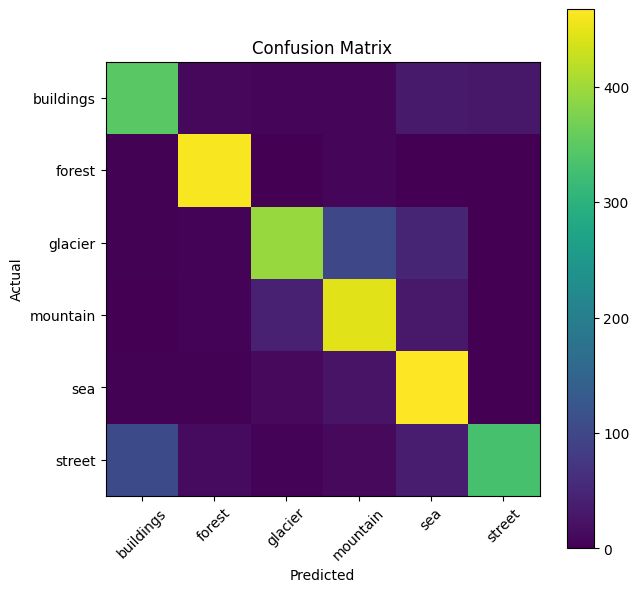

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7, 7))
plt.imshow(cm)

plt.xticks(
    range(6),
    train_data.classes,
    rotation=45
)

plt.yticks(
    range(6),
    train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

## small filters that detect useful visual patterns in RGB images, gradually compressing those patterns into 128 learned features, and then using those features to choose one of six natural-scene classes.

In [15]:
from google.colab import files

uploaded = files.upload()

Saving mountian.jpg to mountian.jpg


In [17]:
from PIL import Image
import torch

def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = test_transform(image).unsqueeze(0)  # Add batch dimension
    image = image.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs.data, 1)

    print(f"Predicted class: {train_data.classes[predicted.item()]}")

image_path = list(uploaded.keys())[0]
predict_image(image_path)

Predicted class: glacier


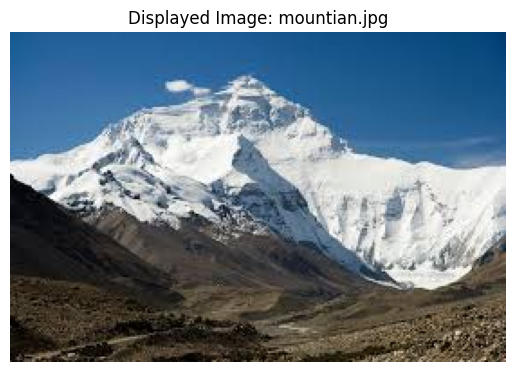

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

# Load the image using PIL
img = Image.open(image_path)

# Display the image using matplotlib
plt.imshow(img)
plt.axis('off') # Hide axes ticks
plt.title(f'Displayed Image: {image_path}')
plt.show()